In [22]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import time

In [35]:
# parameters
n = 200                 # number of data points
d = 2                   # number of features (fixed to 2 for visualization)
k = 4                   # number of means
num_iters = 20          # number of iterations
delay = 0.5             # pause between frames (seconds)

In [36]:
# create synthetic data (clusters use Gaussian blobs for better demonstration)
from sklearn.datasets import make_blobs
data, _ = make_blobs(n_samples=n, centers=k, cluster_std=10)

# randomly initialize means within the data range
means = data[np.random.choice(range(n), k, replace=False)]

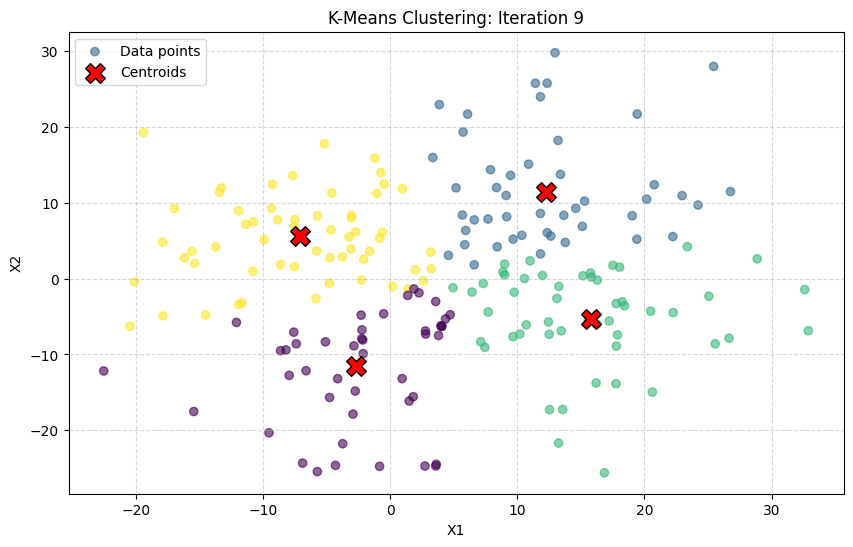

In [ ]:
# K-Means loop with live graphing
for i in range(num_iters):
    # 1. Assignment step: calculate distances to means
    dists = np.linalg.norm(data[:, np.newaxis, :] - means[np.newaxis, :, :], axis=2)
    labels = np.argmin(dists, axis=1)

    # 2. Visual update
    clear_output(wait=True)
    plt.figure(figsize=(10, 6))
    
    # Plot data points colored by cluster
    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', alpha=0.6, label='Data points')
    
    # Plot current means
    plt.scatter(means[:, 0], means[:, 1], c='red', marker='X', s=200, edgecolors='black', label='Centroids')
    
    plt.title(f'K-Means Clustering: Iteration {i+1}')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
    
    # 3. Update step: move means to the center of their clusters
    new_means = np.array([data[labels == j].mean(axis=0) if len(data[labels == j]) > 0 else means[j] for j in range(k)])
    
    # Check for convergence (if means stop moving)
    if np.allclose(means, new_means):
        print(f"Converged at iteration {i+1}!")
        break
        
    means = new_means
    time.sleep(delay)